# Machine Learning Foundation

## Section 2, Part d:  Regularization and Gradient Descent


## Introduction

We will begin with a short tutorial on regression, polynomial features, and regularization based on a very simple, sparse data set that contains a column of `x` data and associated `y` noisy data. The data file is called `X_Y_Sinusoid_Data.csv`.


## Exploration 1 - Real World Data vs Theoretical Data

*   Import the data.

*   Also generate approximately 100 equally spaced x data points over the range of 0 to 1. Using these points, calculate the y-data which represents the "ground truth" (the real function - a sine wave) from the equation: $y = sin(2\pi x)$

*   Plot the sparse imported data (`x` vs `y`), and the calculated ("real" sine wave) data.


In [1]:
import pandas as pd
import numpy as np

# import data
# data_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-ML240EN-SkillsNetwork/labs/data/X_Y_Sinusoid_Data.csv"
data = pd.read_csv("data/X_Y_Sinusoid_Data.csv")
display(data.head())

# generate theoretical Sine Wave data
X_real = np.linspace(0, 1.0, 100)
Y_real = np.sin(2 * np.pi * X_real)

,x,y
0,0.038571,0.066391
1,0.166776,1.027483
2,0.183153,1.245302
3,0.187359,1.004781
4,0.243116,1.264121


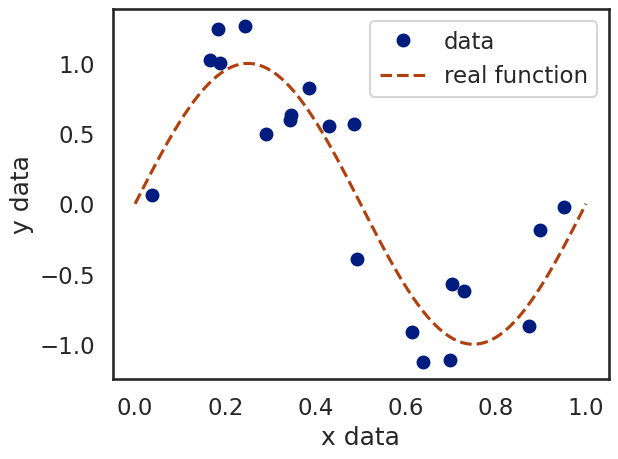

In [2]:
# plot both the imported data, and the generated Sine Wave data
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('white')
sns.set_context('talk')
sns.set_palette('dark')

ax = data.set_index('x')['y'].plot(ls='', marker='o', label='data') # plot imported data points
ax.plot(X_real, Y_real, ls='--', marker='', label='real function')  # plot generated sine wave line

ax.legend()
ax.set(xlabel='x data', ylabel='y data');


## Exploration 2 - Adding Polynomial Features

*   Using the `PolynomialFeatures` class from Scikit-learn's preprocessing library, create 20th order polynomial features.
*   Fit the imported "Real World" data from previous step using linear regression.
*   Plot the resulting predicted value compared to the calculated data.

Note that `PolynomialFeatures` requires either a dataframe (with one column, not a Series) or a 2D array of dimension (`X`, 1), where `X` is the length (row).


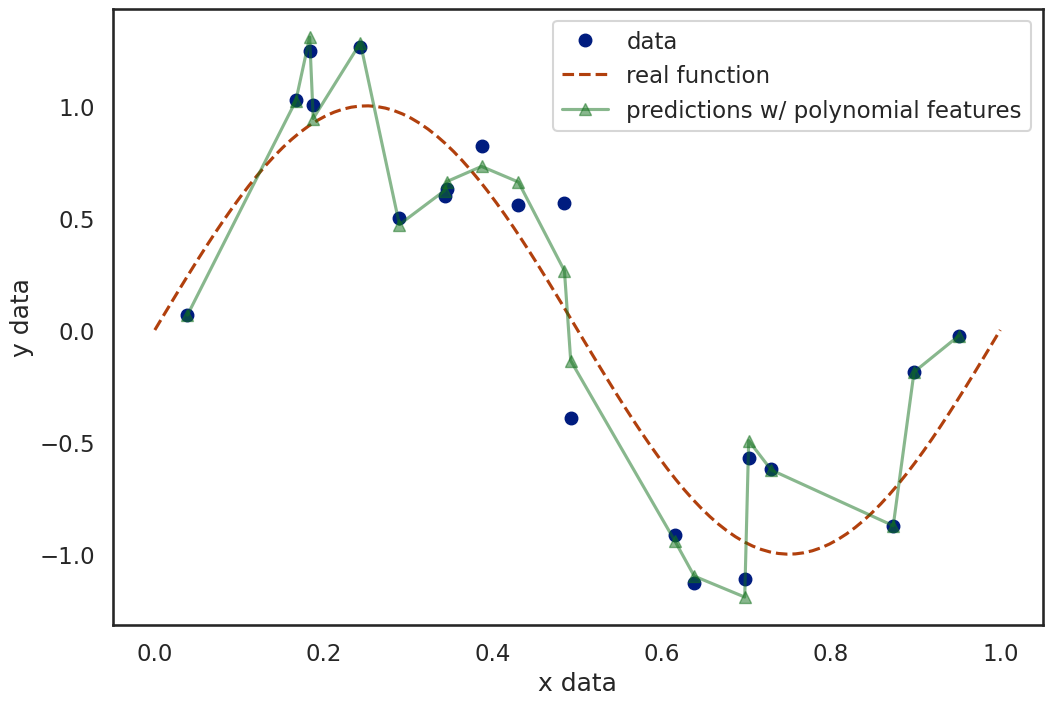

In [3]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

# Setup the polynomial features
degree = 20
pf = PolynomialFeatures(degree)
lr = LinearRegression()

# Extract the X- and Y- data from the dataframe 
X_data = data[['x']]  # double-bracket is needed to return a dataframe since pf.fit_transform() expects a dataframe or 2D array
Y_data = data['y']    # does not need double-bracket since lr.fit() can accept a Series or 1D array

# Create the features and fit the model
X_poly = pf.fit_transform(X_data) # create polynomial-features
lr = lr.fit(X_poly, Y_data)
Y_pred = lr.predict(X_poly)

# Plot the result
plt.figure(figsize=(12,8))
plt.plot(X_data, Y_data, marker='o', ls='', label='data', alpha=1) # plot each data points from data as per before
plt.plot(X_real, Y_real, ls='--', label='real function') # plot the theoretical sine wave as per before
plt.plot(X_data, Y_pred, marker='^', alpha=.5, label='predictions w/ polynomial features') # plot the model's predicted result
plt.legend()
ax = plt.gca()
ax.set(xlabel='x data', ylabel='y data');


As shown above, the predicted plot shows a very Overfitted model since we applied a very high polynomial degree = 20.

<BR>

___
### **Additional Notes on Bias and Variance in ML Models**

Bias and Variance are the two primary sources of error in any machine learning model. Understanding them is the secret to moving from a "decent" model to a "great" one. There are primarily two different ways our model can go wrong:

1. **Bias: The Error of "Simplification"**
* Bias is the difference between the average prediction of our model and the actual value we are trying to predict.
    * **What it represents:** How much our model makes "too simple" assumptions about the data.
    * **Result: Underfitting.** The model is too rigid, meaning it does not bend/curve where needed. It misses the underlying patterns in the data because it is looking at the problem through a lens that is too narrow.
    * **Example:** Trying to model the complex price fluctuations of housing with a simple straight line (Linear Regression) when the data is actually a complex curve. The line does not capture the shape of the data.

2. **Variance: The Error of "Sensitivity"**
* Variance tells us how much our model's prediction would change if we trained it on a different set of data (e.g. Train vs Test).
    * **What it represents:** How much our model "over-thinks" the training data. It captures the noise and random fluctuations in the training set as if they were real patterns.
    * **Result:** Overfitting. The model is too flexible, meaning it connects very closely to every data points. It performs perfectly on the training data but fails miserably when we give it new, unseen data (the "test" set).
    * **Example:** A model that connects every single data point with a squiggly, complex line (see the green color plot above). It fits the training data perfectly, but it's useless for predicting anything else.

We cannot typically have both low bias and low variance simultaneously. This is the core challenge of data science.
* **If we increase model complexity** (e.g. adding more polynomial features), **the bias will decrease** (the model fits the training data better). But this will **increase the variance** and makes the model too sensitive to that specific training data set.
* **If we decrease model complexity** (e.g. simplifying the model), we **increase the bias** (the model becomes too rigid). But this **decrease the variance** and the model become more stable and less sensitive to specific training data set.

To overcome the above, models such as Ridge and Lasso Regression introduce **Regularization**. Regularization is a tool to manage the Bias-Variance Trade-off.

**In Summary:**
* **High Bias** = The model is too simple (Underfitting)
* **High Variance** = The model is too complex (Overfitting)
* **Our Goal** = Find the sweet spot where the sum of these errors is minimized.

___

<BR>

## Exploration 3 - Ridge & Lasso Regression models

*   Perform the regression on using the data with polynomial features using ridge regression ($\alpha$=0.001) and lasso regression ($\alpha$=0.0001).
*   Plot the results, as was done in Exploration 1.
*   Also plot the magnitude of the coefficients obtained from these regressions, and compare them to those obtained from linear regression in the previous exploration. The linear regression coefficients will likely need a separate plot (or their own y-axis) due to their large magnitude.

What does the comparatively large magnitude of the data tell you about the role of regularization (specified as $\alpha$ values)?


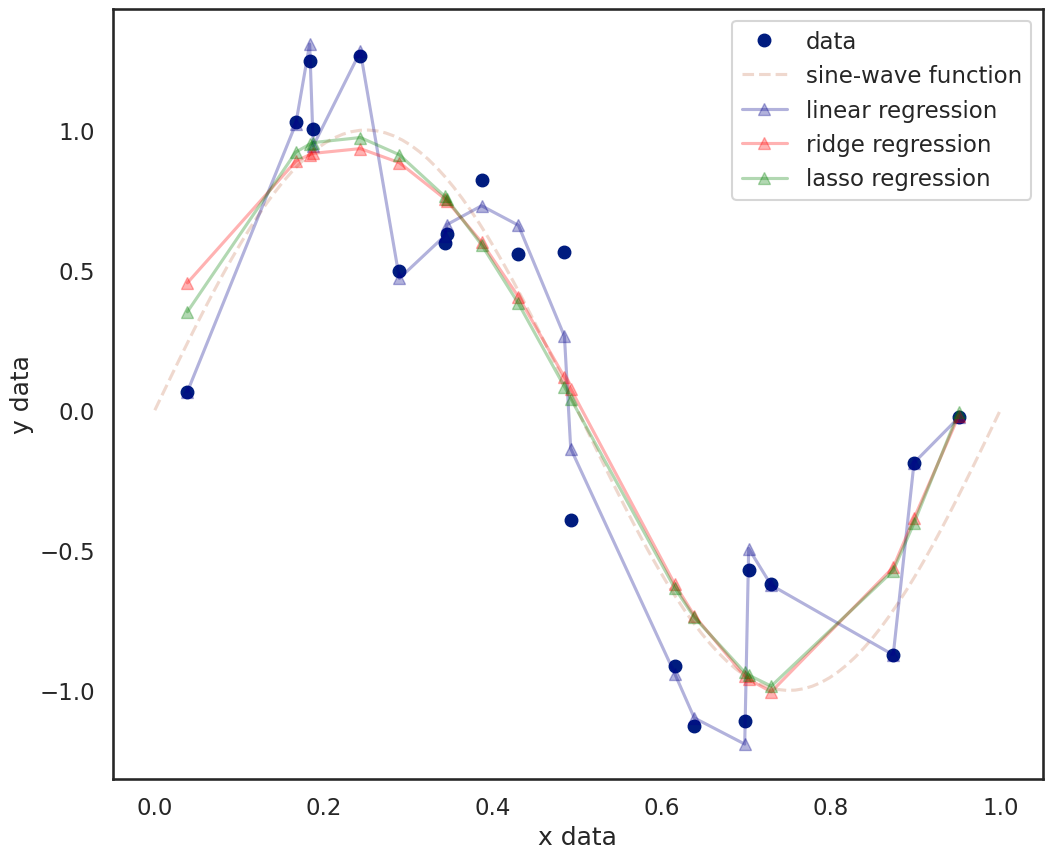

In [4]:
# Mute the sklearn warning about regularization
import warnings
warnings.filterwarnings('ignore', module='sklearn')

from sklearn.linear_model import Ridge, Lasso

# The ridge regression model
rr = Ridge(alpha=0.001)
rr = rr.fit(X_poly, Y_data)
Y_pred_rr = rr.predict(X_poly)

# The lasso regression model
lassor = Lasso(alpha=0.0001)
lassor = lassor.fit(X_poly, Y_data)
Y_pred_lr = lassor.predict(X_poly)

# The plot of the predicted values
plt.figure(figsize=(12,10))
plt.plot(X_data, Y_data, marker='o', ls='', label='data') # data points as per previous step
plt.plot(X_real, Y_real, ls='--', label='sine-wave function', alpha=0.2)  # sine-wave line as per previous step
plt.plot(X_data, Y_pred,    label='linear regression', marker='^', alpha=.3, color='darkblue') # predicted line with high polynomial features as per previous step
plt.plot(X_data, Y_pred_rr, label='ridge regression',  marker='^', alpha=.3, color='red') # ridge predicted line with regularization
plt.plot(X_data, Y_pred_lr, label='lasso regression',  marker='^', alpha=.3, color='green')  # lasso predicted line with regularization

plt.legend()

ax = plt.gca()
ax.set(xlabel='x data', ylabel='y data');

In [5]:
# let's look at the absolute value of coefficients for each model

coefficients = pd.DataFrame()
coefficients['linear regression'] = lr.coef_
coefficients['ridge regression'] = rr.coef_
coefficients['lasso regression'] = lassor.coef_
coefficients = coefficients.map(abs) # transform into absolute values

print("coefficients:")
display(coefficients.head())

print("\ncoefficients.describe():")
display(coefficients.describe())  # Huge difference in scale between non-regularized vs regularized regression

coefficients:


,linear regression,ridge regression,lasso regression
0,2.008356e+08,0.000000,0.000000
1,1.866875e+06,6.065176,8.490500
2,4.539975e+07,12.429635,20.176708
3,6.133840e+08,4.070127,1.641353
4,5.270459e+09,2.307194,5.698488



coefficients.describe():


,linear regression,ridge regression,lasso regression
count,2.100000e+01,21.000000,21.000000
mean,2.427786e+11,2.169397,2.167284
std,2.709998e+11,2.900278,4.706731
min,1.866875e+06,0.000000,0.000000
25%,3.076136e+10,0.467578,0.000000
50%,1.258321e+11,1.017272,0.252181
75%,3.631114e+11,2.883507,1.641353
max,9.201049e+11,12.429635,20.176708


As shown above, there is a huge difference in scale between non-regularized vs regularized regression coefficient values. Regularized Regression models apply standardization internally as it will also apply the same Regularization Factor, alpha, to the features. Hence, features with different unit values can have a serious adversed effect if they are not standized. In contrast, for Non-regularized Regression models, such as Linear Regression, standardization is optional as there is no regularization factor applied.

We can visualize the coefficients values comparison in the following plots. It is hard to see the coeffients of each features for the Linear Regression model due to the big difference in scale relative to the other two models.

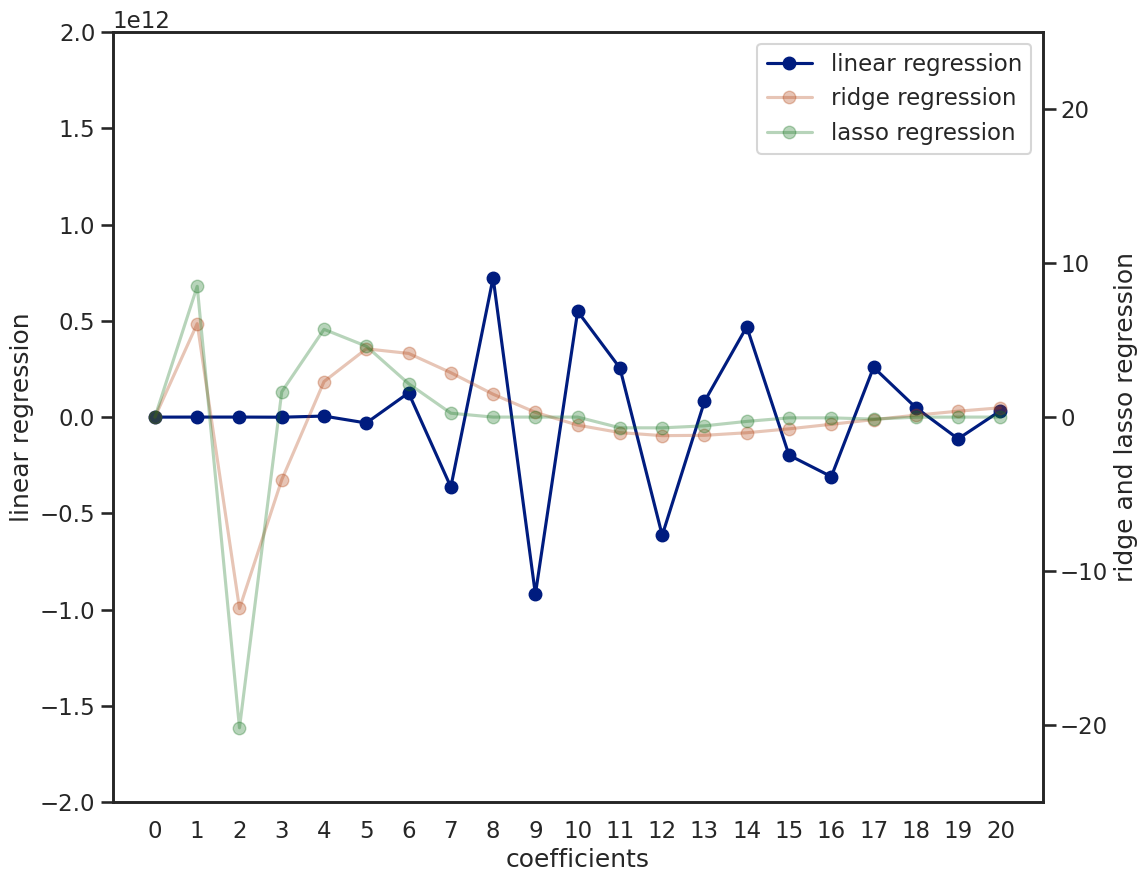

In [6]:
colors = sns.color_palette()
plt.figure(figsize=(12, 10))

# Setup the dual y-axes
ax1 = plt.axes()
ax2 = ax1.twinx()

# Plot the linear regression data
ax1.plot(lr.coef_.ravel(), color=colors[0], marker='o', label='linear regression')

# Plot the regularization data sets
ax2.plot(rr.coef_.ravel(),     color=colors[1], alpha=0.3, marker='o', label='ridge regression')
ax2.plot(lassor.coef_.ravel(), color=colors[2], alpha=0.3, marker='o', label='lasso regression')

# Customize axes scales
ax1.set_ylim(-2e12, 2e12)
ax2.set_ylim(-25, 25)

# Combine the legends
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1+h2, l1+l2)

ax1.set(xlabel='coefficients',ylabel='linear regression')
ax2.set(ylabel='ridge and lasso regression')

ax1.set_xticks(range(len(lr.coef_)));

<BR>

___
### **Additional Notes on Regularization**

Regularization is essentially a way to prevent your machine learning models from becoming too complex. It "penalizes" large coefficients in the model, forcing them to be smaller and more stable, which in turn helps the model generalize better to new data.

The fundamental difference between L1 (used in Lasso) and L2 (used in Ridge) lies in how they apply that penalty to the coefficients. L1 Regularization in Lasso drives coefficients to **exactly 0**, and this results in a "sparse" model in terms of feature selection. L2 Regularization in Ridge drives coefficients **towards 0** but rarely 0, hence it keeps all features, but shrinks their weights.

Use L1 (Lasso) when only a few features in the dataset are actually important. It is excellent for simplifying the model and making it easier to interpret.

Use L2 (Ridge) when most of the features are useful and contribute to the outcome. It is generally the "default" choice for many regression tasks because it is more stable and does not randomly exclude features.

We can also use **Elastic Net**, which combines both L1 and L2 into a single formula giving us the best of both worlds.
___

<BR>

## Exploration 4 - Switching to a DataSet with multiple Categorical Features.

For the remaining questions, we will be working with the [data set](https://www.kaggle.com/c/house-prices-advanced-regression-techniques?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML240ENSkillsNetwork34171862-2022-01-01) from last lesson, which is based on housing prices in Ames, Iowa. There are an extensive number of features--see the exercises from week three for a discussion of these features.

To begin:

*   Import the data with Pandas, remove any null values, and one hot encode categoricals. Either Scikit-learn's feature encoders or Pandas `get_dummies` method can be used.
*   Split the data into train and test sets.
*   Log transform skewed features.
*   Scaling can be attempted, although it can be interesting to see how well regularization works without scaling features.


In [7]:
# data_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-ML240EN-SkillsNetwork/labs/data/Ames_Housing_Sales.csv"
data = pd.read_csv("data/Ames_Housing_Sales.csv")
data.head(10)

,1stFlrSF,2ndFlrSF,3SsnPorch,Alley,BedroomAbvGr,BldgType,BsmtCond,BsmtExposure,BsmtFinSF1,BsmtFinSF2,...,ScreenPorch,Street,TotRmsAbvGrd,TotalBsmtSF,Utilities,WoodDeckSF,YearBuilt,YearRemodAdd,YrSold,SalePrice
0,856.0,854.0,0.0,NaN,3,1Fam,TA,No,706.0,0.0,...,0.0,Pave,8,856.0,AllPub,0.0,2003,2003,2008,208500.0
1,1262.0,0.0,0.0,NaN,3,1Fam,TA,Gd,978.0,0.0,...,0.0,Pave,6,1262.0,AllPub,298.0,1976,1976,2007,181500.0
2,920.0,866.0,0.0,NaN,3,1Fam,TA,Mn,486.0,0.0,...,0.0,Pave,6,920.0,AllPub,0.0,2001,2002,2008,223500.0
3,961.0,756.0,0.0,NaN,3,1Fam,Gd,No,216.0,0.0,...,0.0,Pave,7,756.0,AllPub,0.0,1915,1970,2006,140000.0
4,1145.0,1053.0,0.0,NaN,4,1Fam,TA,Av,655.0,0.0,...,0.0,Pave,9,1145.0,AllPub,192.0,2000,2000,2008,250000.0
5,796.0,566.0,320.0,NaN,1,1Fam,TA,No,732.0,0.0,...,0.0,Pave,5,796.0,AllPub,40.0,1993,1995,2009,143000.0
6,1694.0,0.0,0.0,NaN,3,1Fam,TA,Av,1369.0,0.0,...,0.0,Pave,7,1686.0,AllPub,255.0,2004,2005,2007,307000.0
7,1107.0,983.0,0.0,NaN,3,1Fam,TA,Mn,859.0,32.0,...,0.0,Pave,7,1107.0,AllPub,235.0,1973,1973,2009,200000.0
8,1022.0,752.0,0.0,NaN,2,1Fam,NaN,NaN,0.0,0.0,...,0.0,Pave,8,952.0,AllPub,90.0,1931,1950,2008,129900.0
9,1077.0,0.0,0.0,NaN,2,2fmCon,TA,No,851.0,0.0,...,0.0,Pave,5,991.0,AllPub,0.0,1939,1950,2008,118000.0


Create a list of categorial data and one-hot encode. Pandas one-hot encoder (`get_dummies`) works well with data that is defined as a categorical.


In [8]:
data =pd.get_dummies(data, drop_first=True)
data.columns

Index(['1stFlrSF', '2ndFlrSF', '3SsnPorch', 'BedroomAbvGr', 'BsmtFinSF1',
       'BsmtFinSF2', 'BsmtFullBath', 'BsmtHalfBath', 'BsmtUnfSF',
       'EnclosedPorch',
       ...
       'SaleType_CWD', 'SaleType_Con', 'SaleType_ConLD', 'SaleType_ConLI',
       'SaleType_ConLw', 'SaleType_New', 'SaleType_Oth', 'SaleType_WD',
       'Street_Pave', 'Utilities_NoSeWa'],
      dtype='str', length=241)

The dataset has been transform from 80 columns to 241 columns after One-Hot Encoding for the Categorical features.

Next, we split the data into train and test data sets with a test-size of 30%.

In [9]:
from sklearn.model_selection import train_test_split

train, test = train_test_split(data, test_size=0.3, random_state=42)

There are a number of columns that have skewed features--a log transformation can be applied to them. Note that this includes the `SalePrice`, our predictor. However, let's keep that one as is.

We will only applied the Log transformation on features that are skewed above 75%.

In [10]:
# Create a list of float columns to check for skewing
mask = data.dtypes == float
float_cols = data.columns[mask]

skew_limit = 0.75
skew_vals = train[float_cols].skew()

skew_cols = (skew_vals
             .sort_values(ascending=False)
             .to_frame()
             .rename(columns={0:'Skew'})
             .query('abs(Skew) > {0}'.format(skew_limit)))

skew_cols

,Skew
MiscVal,26.915364
PoolArea,15.777668
LotArea,11.501694
LowQualFinSF,11.210638
3SsnPorch,10.150612
ScreenPorch,4.599803
BsmtFinSF2,4.466378
EnclosedPorch,3.218303
LotFrontage,3.138032
MasVnrArea,2.492814


Transform all the columns where the skew is greater than 0.75, excluding "SalePrice".


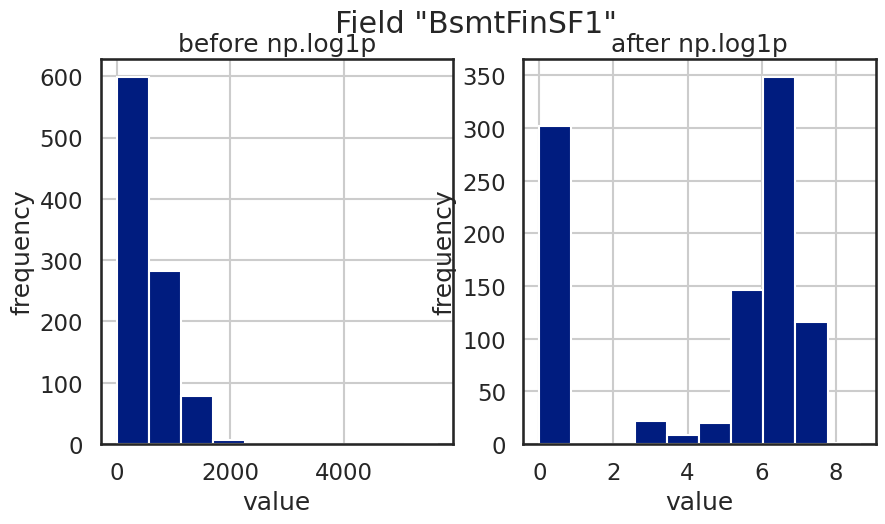

In [11]:
# Before applying the log transform to all the features, let's look at what happens to one of these features, when we apply np.log1p visually.

field = "BsmtFinSF1"
fig, (ax_before, ax_after) = plt.subplots(1, 2, figsize=(10, 5))
train[field].hist(ax=ax_before)
train[field].apply(np.log1p).hist(ax=ax_after)
ax_before.set(title='before np.log1p', ylabel='frequency', xlabel='value')
ax_after.set(title='after np.log1p', ylabel='frequency', xlabel='value')
fig.suptitle('Field "{}"'.format(field));
# a little bit better

Now we apply the log-transform to all the skewed features we identified for both the Training and Test datasets.

In [12]:
# Mute the setting wtih a copy warnings
pd.options.mode.chained_assignment = None

for col in skew_cols.index.tolist():
    if col == "SalePrice": # ignore the SalePrice column as per our requirement
        continue
    train[col] = np.log1p(train[col])
    test[col]  = test[col].apply(np.log1p)

Separate features from predictor.


In [13]:
feature_cols = [x for x in train.columns if x != 'SalePrice']
X_train = train[feature_cols]
y_train = train['SalePrice']

X_test  = test[feature_cols]
y_test  = test['SalePrice']

## Exploration 5 - Root-Mean-Square Error calculation function

*   Write a function **`rmse`** that takes in truth and prediction values and returns the root-mean-squared error. Use sklearn's `mean_squared_error`.


In [14]:
from sklearn.metrics import mean_squared_error


def rmse(ytrue, ypredicted):
    return np.sqrt(mean_squared_error(ytrue, ypredicted))

*   Fit a basic linear regression model
*   print the root-mean-squared error for this model
*   plot the predicted vs actual sale price based on the model.


In [15]:
from sklearn.linear_model import LinearRegression

linearRegression = LinearRegression().fit(X_train, y_train)

linearRegression_rmse = rmse(y_test, linearRegression.predict(X_test))

print(linearRegression_rmse)

42033.492152799496


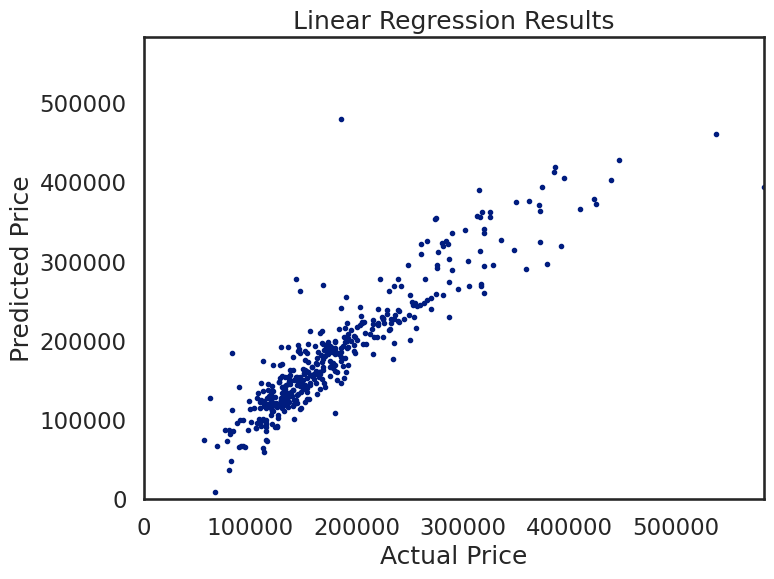

In [16]:
f = plt.figure(figsize=(8,6))
ax = plt.axes()

ax.plot(y_test, linearRegression.predict(X_test), marker='o', ls='', ms=3.0)

lim = (0, y_test.max())

ax.set(xlabel='Actual Price', 
       ylabel='Predicted Price', 
       xlim=lim,
       ylim=lim,
       title='Linear Regression Results');

## Exploration 6 - Ridge Regression with Cross Validation

Ridge regression uses L2 normalization to reduce the magnitude of the coefficients. This can be helpful in situations where there is high variance. The regularization functions in Scikit-learn each contain versions that have cross-validation built in.

*   Fit a RidgeCV model to a range of $\alpha$ values.
*   Use [0.005, 0.05, 0.1, 0.3, 1, 3, 5, 10, 15, 30, 80] as the range of alphas.
*   Then repeat the fitting of the Ridge models using the range of $\alpha$ values from the prior section. Compare the results.


Now for the `RidgeCV` method. It's not possible to get the alpha values for the models that weren't selected, unfortunately. The resulting error values and $\alpha$ values are very similar to those obtained above.


In [17]:
from sklearn.linear_model import RidgeCV

alphas = [0.005, 0.05, 0.1, 0.3, 1, 3, 5, 10, 15, 30, 80]

ridgeCV = RidgeCV(alphas=alphas, cv=4).fit(X_train, y_train) # RidgeCV automatically loop through the alphas list for the optimised alpha value

ridgeCV_rmse = rmse(y_test, ridgeCV.predict(X_test))

print(ridgeCV.alpha_, ridgeCV_rmse) # ridgeCV.alpha_ is the optimised alpha value

10.0 32022.031469901194


## Exploration 7 - Lasso Regression with Cross Validation

Much like the `RidgeCV` function, there is also a `LassoCV` function that uses an L1 regularization function and cross-validation. L1 regularization will selectively shrink some coefficients, effectively performing feature elimination.

The `LassoCV` function does not allow the scoring function to be set. However, the custom error function (`rmse`) created above can be used to evaluate the error on the final model.

Similarly, there is also an elastic net function with cross validation, `ElasticNetCV`, which is a combination of L2 and L1 regularization.

*   Fit a Lasso model using cross validation and determine the optimum value for $\alpha$ and the RMSE using the function created above. Note that the magnitude of $\alpha$ may be different from the Ridge model.
*   Repeat this with the Elastic net model.
*   Compare the results via table and/or plot.

Use the following alphas:\
`[0.005, 0.05, 0.1, 1, 5, 20, 50, 80, 100, 120, 140]`


In [18]:
from sklearn.linear_model import LassoCV

# alphas2 = np.array([1e-5, 5e-5, 0.0001, 0.0005])
alphas2 = np.array([0.005, 0.05, 0.1, 1, 5, 20, 50, 80, 100, 120, 140, 160, 180])

# lassoCV = LassoCV(alphas=alphas2, max_iter=int(5e4), cv=3).fit(X_train, y_train)
lassoCV = LassoCV(alphas=alphas2, max_iter=int(5e4), cv=4).fit(X_train, y_train)

lassoCV_rmse = rmse(y_test, lassoCV.predict(X_test))

print(lassoCV.alpha_, lassoCV_rmse)  # Lasso is slower

160.0 35372.80614653755


We can determine how many of these features remain non-zero.


In [19]:
print('Of {} coefficients, {} are non-zero with Lasso.'.format(len(lassoCV.coef_), len(lassoCV.coef_.nonzero()[0])))

Of 240 coefficients, 88 are non-zero with Lasso.


Now try the elastic net, with the same alphas as in Lasso, and l1\_ratios between 0.1 and 0.9


In [20]:
from sklearn.linear_model import ElasticNetCV

l1_ratios = np.linspace(0.1, 0.9, 9)  # use as weight for balancing the alpha values from Ridge to Lasso

elasticNetCV = ElasticNetCV(alphas=alphas2, l1_ratio=l1_ratios, max_iter=int(1e4)).fit(X_train, y_train)
elasticNetCV_rmse = rmse(y_test, elasticNetCV.predict(X_test))

print(elasticNetCV.alpha_, elasticNetCV.l1_ratio_, elasticNetCV_rmse)

0.05 0.7000000000000001 31946.20397501748


Comparing the RMSE calculation from all models is easiest in a table.


In [21]:
rmse_vals = [linearRegression_rmse, ridgeCV_rmse, lassoCV_rmse, elasticNetCV_rmse]

labels = ['Linear', 'Ridge', 'Lasso', 'ElasticNet']

rmse_df = pd.Series(rmse_vals, index=labels).to_frame()
rmse_df.rename(columns={0: 'RMSE'}, inplace=1)
rmse_df

,RMSE
Linear,42033.492153
Ridge,32022.031470
Lasso,35372.806147
ElasticNet,31946.203975


We can also make a plot of actual vs predicted housing prices as before.


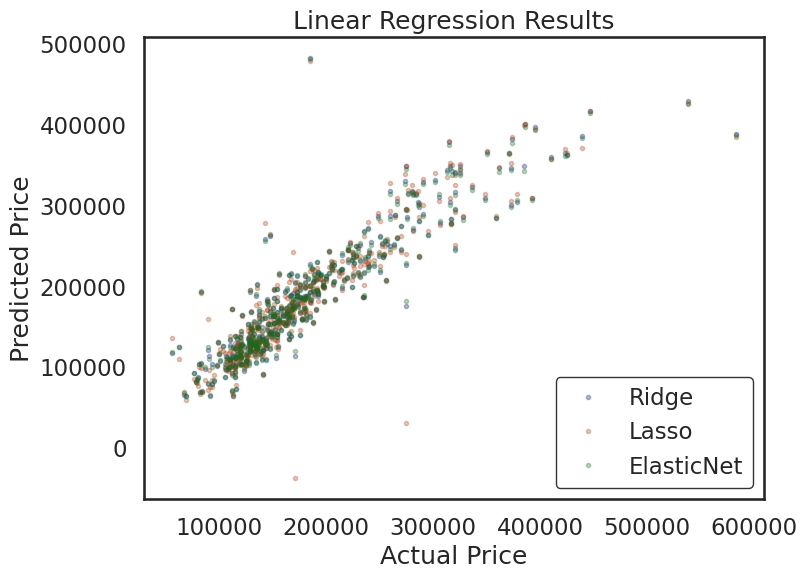

In [22]:
f = plt.figure(figsize=(8,6))
ax = plt.axes()

labels = ['Ridge', 'Lasso', 'ElasticNet']

models = [ridgeCV, lassoCV, elasticNetCV]

for mod, lab in zip(models, labels):
    ax.plot(y_test, mod.predict(X_test), marker='o', ls='', ms=3.0, label=lab, alpha=0.3)


leg = plt.legend(frameon=True)
leg.get_frame().set_edgecolor('black')
leg.get_frame().set_linewidth(1.0)

ax.set(xlabel='Actual Price', 
       ylabel='Predicted Price', 
       title='Linear Regression Results');

## Exploration 8 - Gradient Descent (SGD)

Let's explore Stochastic gradient descent in this exercise.\
Recall that Linear models in general are sensitive to scaling.
However, SGD is *very* sensitive to scaling.\
Moreover, a high value of learning rate can cause the algorithm to diverge, whereas a too low value may take too long to converge.

*   Fit a stochastic gradient descent model without a regularization penalty (the relevant parameter is `penalty`).
*   Now fit stochastic gradient descent models with each of the three penalties (L2, L1, Elastic Net) using the parameter values determined by cross validation above.
*   Do not scale the data before fitting the model.
*   Compare the results to those obtained without using stochastic gradient descent.


In [23]:
# Import SGDRegressor and prepare the parameters

from sklearn.linear_model import SGDRegressor

model_parameters_dict = {
    'Linear'     : {'penalty': None},
    'Lasso'      : {'penalty': 'l2', 'alpha': lassoCV.alpha_},
    'Ridge'      : {'penalty': 'l1', 'alpha': ridgeCV_rmse},
    'ElasticNet' : {'penalty': 'elasticnet', 'alpha': elasticNetCV.alpha_, 'l1_ratio': elasticNetCV.l1_ratio_}
}

new_rmses = {}
for modellabel, parameters in model_parameters_dict.items():
    # following notation passes the dict items as arguments
    SGD = SGDRegressor(**parameters)
    SGD.fit(X_train, y_train)
    new_rmses[modellabel] = rmse(y_test, SGD.predict(X_test))

rmse_df['RMSE-SGD'] = pd.Series(new_rmses)
rmse_df

,RMSE,RMSE-SGD
Linear,42033.492153,2.943733e+15
Ridge,32022.031470,1.324238e+16
Lasso,35372.806147,2.597111e+15
ElasticNet,31946.203975,1.284067e+14


Notice how high the error values are! The algorithm is diverging. This can be due to scaling and/or learning rate being too high. Let's adjust the learning rate and see what happens.

*   Pass in `eta0=1e-7` when creating the instance of `SGDClassifier`.
*   Re-compute the errors for all the penalties and compare.


In [24]:
# Import SGDRegressor and prepare the parameters

from sklearn.linear_model import SGDRegressor

model_parameters_dict = {
    'Linear'    : {'penalty': None},
    'Lasso'     : {'penalty': 'l2', 'alpha': lassoCV.alpha_},
    'Ridge'     : {'penalty': 'l1', 'alpha': ridgeCV_rmse},
    'ElasticNet': {'penalty': 'elasticnet', 'alpha': elasticNetCV.alpha_, 'l1_ratio': elasticNetCV.l1_ratio_}
}

new_rmses = {}
for modellabel, parameters in model_parameters_dict.items():
    # following notation passes the dict items as arguments
    SGD = SGDRegressor(eta0=1e-7, **parameters)
    SGD.fit(X_train, y_train)
    new_rmses[modellabel] = rmse(y_test, SGD.predict(X_test))

rmse_df['RMSE-SGD-learningrate'] = pd.Series(new_rmses)
rmse_df

,RMSE,RMSE-SGD,RMSE-SGD-learningrate
Linear,42033.492153,2.943733e+15,74066.964233
Ridge,32022.031470,1.324238e+16,74969.056717
Lasso,35372.806147,2.597111e+15,71886.047321
ElasticNet,31946.203975,1.284067e+14,71410.322006


Now let's scale our training data and try again.

*   Fit a `MinMaxScaler` to `X_train` create a variable `X_train_scaled`.
*   Using the scaler, transform `X_test` and create a variable `X_test_scaled`.
*   Apply the same versions of SGD to them and compare the results. Don't pass in a eta0 this time.


In [25]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

new_rmses = {}
for modellabel, parameters in model_parameters_dict.items():
    # following notation passes the dict items as arguments
    SGD = SGDRegressor(**parameters)
    SGD.fit(X_train_scaled, y_train)
    new_rmses[modellabel] = rmse(y_test, SGD.predict(X_test_scaled))

rmse_df['RMSE-SGD-scaled'] = pd.Series(new_rmses)
rmse_df

,RMSE,RMSE-SGD,RMSE-SGD-learningrate,RMSE-SGD-scaled
Linear,42033.492153,2.943733e+15,74066.964233,32660.179837
Ridge,32022.031470,1.324238e+16,74969.056717,77777.787267
Lasso,35372.806147,2.597111e+15,71886.047321,77264.791548
ElasticNet,31946.203975,1.284067e+14,71410.322006,32282.132727


In [26]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

new_rmses = {}
for modellabel, parameters in model_parameters_dict.items():
    # following notation passes the dict items as arguments
    SGD = SGDRegressor(eta0=1e-7, **parameters)
    SGD.fit(X_train_scaled, y_train)
    new_rmses[modellabel] = rmse(y_test, SGD.predict(X_test_scaled))

rmse_df['RMSE-SGD-scaled'] = pd.Series(new_rmses)
rmse_df

,RMSE,RMSE-SGD,RMSE-SGD-learningrate,RMSE-SGD-scaled
Linear,42033.492153,2.943733e+15,74066.964233,180605.699474
Ridge,32022.031470,1.324238e+16,74969.056717,185321.360542
Lasso,35372.806147,2.597111e+15,71886.047321,185234.701085
ElasticNet,31946.203975,1.284067e+14,71410.322006,180605.935641


<BR>

___
### **Additional Notes: Relating Bias & Variance to Root-Mean-Square Error**

The relationship between Bias, Variance, and RMSE isn't just a conceptual idea; it is a formal mathematical decomposition known as the Bias-Variance Decomposition.

In machine learning, we don't just calculate error by accident; we break it down into three specific parts that add up to your Mean Squared Error (MSE). Since RMSE is just the square root of MSE, it effectively summarizes these three components.

The Fundamental Equation

Mathematically, the total Mean Squared Error (MSE) of your model can be expressed as:

$$\text{MSE} = \text{Bias}^2 + \text{Variance} + \text{Irreducible Error}$$

And since RMSE is the square root of MSE:

$$\text{RMSE} = \sqrt{\text{Bias}^2 + \text{Variance} + \text{Irreducible Error}}$$

**Breaking Down the Components**

1. **$Bias^2$ (Systematic Error)**: This measures the error of your model's average prediction versus the true value. We square it because, in MSE calculation, differences from the truth are squared. If your model is "too rigid" (underfitted), this term dominates your RMSE.

2. **Variance (Sensitivity Error)**: This measures how much your model's predictions fluctuate when you train it on different subsets of data. If your model is "too flexible" (overfitted), this term dominates your RMSE.

3. **Irreducible Error (Noise)**: This is the "noise floor" of your data. It represents random variations in the real world that no model—no matter how perfect—can ever predict (like the random luck involved in house prices or stock market fluctuations). You cannot reduce this part of the RMSE; it is part of the data itself.


There is no model function that will compute the Bias or Variance error. However, we can compute these as estimates using scikit-learn by plotting **Learning Curves**. This will show exactly how much our model is suffering from Bias versus Variance. The most reliable way to visualize this is to plot the training score against the cross-validation score. The following function will generate a learning curve for our regression model. It will visually show if we are underfitting (Bias) or overfitting (Variance).

<BR>

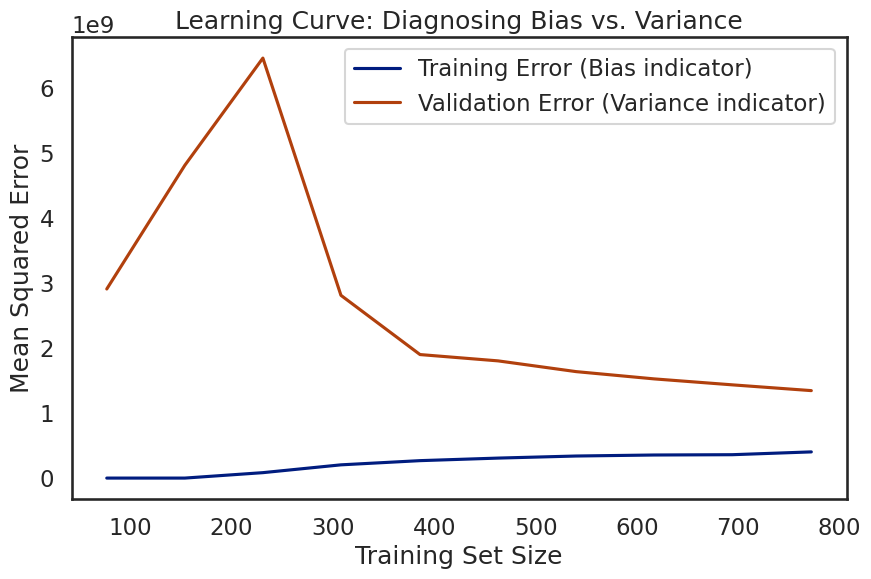

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve

def plot_learning_curve(model, X, y):
    train_sizes, train_scores, val_scores = learning_curve(
        model, X, y, cv=5, n_jobs=-1, 
        train_sizes=np.linspace(0.1, 1.0, 10),
        scoring='neg_mean_squared_error'
    )
    
    # Calculate means for plotting
    train_scores_mean = -np.mean(train_scores, axis=1)
    val_scores_mean = -np.mean(val_scores, axis=1)
    
    plt.figure(figsize=(10, 6))
    plt.plot(train_sizes, train_scores_mean, label='Training Error (Bias indicator)')
    plt.plot(train_sizes, val_scores_mean, label='Validation Error (Variance indicator)')
    plt.xlabel('Training Set Size')
    plt.ylabel('Mean Squared Error')
    plt.legend()
    plt.title('Learning Curve: Diagnosing Bias vs. Variance')
    plt.show()

# Use it on your existing regression model (e.g., lr, rr, or lassor)
plot_learning_curve(lr, X_train, y_train)

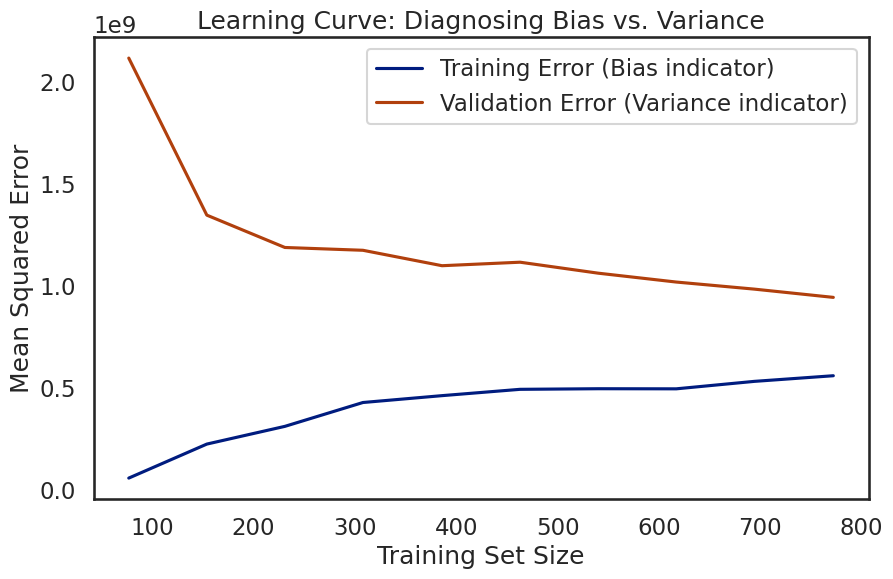

In [28]:
plot_learning_curve(lassoCV, X_train, y_train)

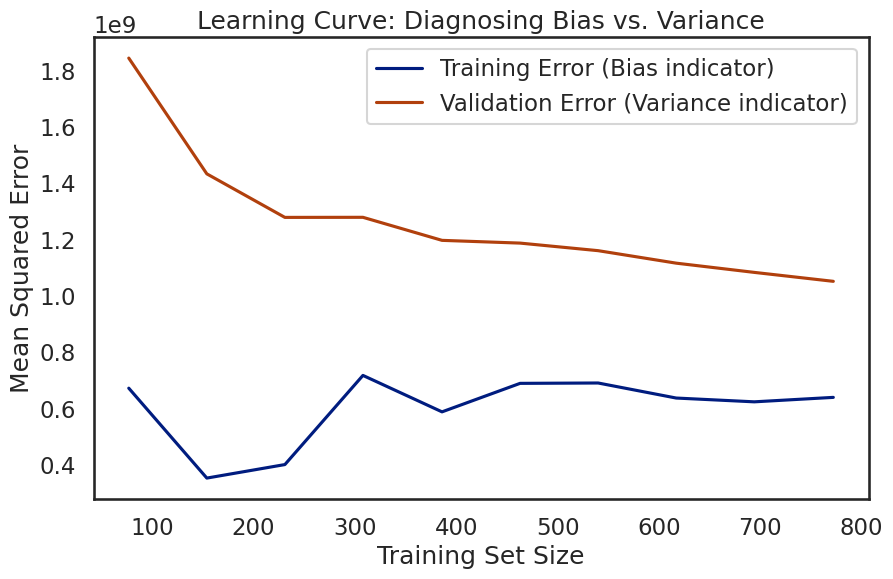

In [29]:
plot_learning_curve(ridgeCV, X_train, y_train)

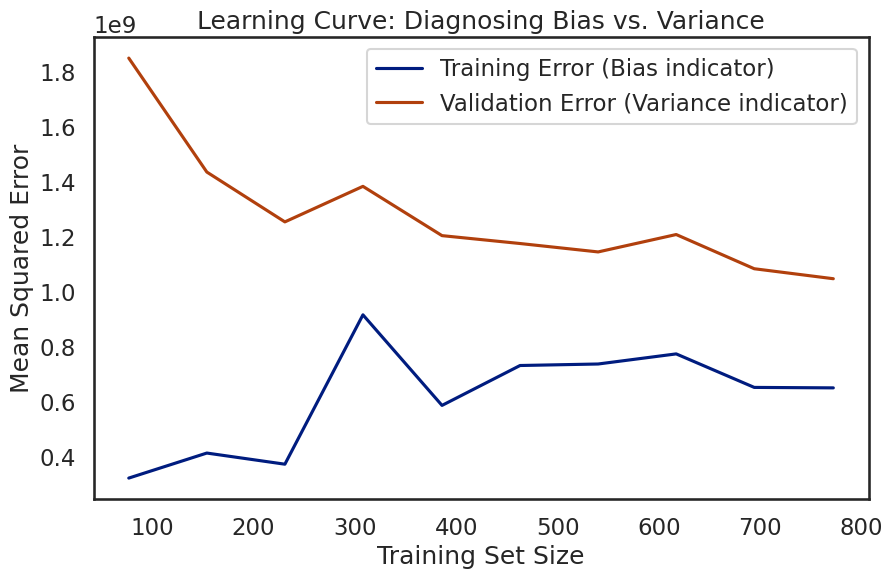

In [30]:
plot_learning_curve(elasticNetCV, X_train, y_train)

### Interpreting the above Learning Curves

When both lines converge as the training set size increases, it is actually in a "stable" state! The crucial part is where they converge.

Think of the "convergence" as the point where the model has finally seen enough data to stop "learning new things" and just starts repeating its performance.

Here is how to interpret exactly what that convergence means for our model:

1. The "Good Fit" (The Goal)

    * What it looks like: Both the training error and validation error lines converge and settle at a low error value.

    * Interpretation: The model has successfully generalized. It’s not overthinking the data (it's not overfitting), and it’s not too simple to capture the pattern (it's not underfitting).

    * Advice: We have achieved a good balance. We can stop here!

2. The "High Bias" (Underfitting)

    * What it looks like: Both lines converge, but they settle at a high error value.

    * Interpretation: Even with all the data in the world, your model is consistently "wrong" by a large margin. It’s too "rigid" to capture the complexity of the housing prices. It's like trying to draw a complex map with only a straight ruler.

    * Advice: The model is too simple.

        * Add more features (feature engineering).

        * Use a more complex model (e.g., Polynomial features).

        * Reduce the amount of Regularization (lower your alpha).

3. The "High Variance" (Overfitting)

    * What it looks like: The lines do not converge. The training error is very low (the model loves the training data), but the validation error is significantly higher (it struggles on the data it hasn't seen).

    * Interpretation: The model is "too flexible." It memorized the noise in your training set perfectly, but that "memorization" doesn't help it when it sees new, unseen houses.

    * Advice: The model is too complex.

        * Gather more data (to dilute the noise).

        * Increase Regularization (make your alpha stronger).

        * Simplify the model (remove noisy/irrelevant features).


When the lines are "trending toward convergence" but haven't actually touched, you are in the "Learning Gap" zone. Whether this means the training set is "too small" depends on the shape of that gap. Here is the diagnostic checklist to see if more data will actually solve the problem or if we need to adjust our model instead.

1. **The "More Data" Hypothesis**: If the training error line is flat (low error) and the validation error line is slowly trending down toward the training line, then the training set is likely too small.

    * **The Logic**: The model is currently "high variance." It has memorized the training set perfectly but doesn't generalize well to the validation set. By adding more data, we give the model more examples of the "truth," which makes it harder for the model to memorize random noise. Eventually, the validation error will drop to meet the training error.

2. **The "Model Complexity" Hypothesis**: If your training error line is flat (low error) and the validation error line is stagnant (it stops decreasing) while still being far above the training line, then more data will NOT help.

    * **The Logic**: The model is simply too complex (overfitted) for the underlying pattern. Even if we gave it 1,000,000 more rows of data, the validation error would stay flat because the model's structure is fundamentally too flexible.

    * **The Fix:** In this case, we don't need more data — we need to increase the Regularization (stronger alpha in Ridge/Lasso/ElasticNet) to "brake" the model's flexibility.

**How to test which one it is**: Look at the Validation Error line at the very end of the plot:

* If it has a negative slope (still going down): We are still gaining performance. If there are more data available (or can perform more cross-validation folds), keep going! We are on the right track.

* If it has flattened out (the slope is near zero): We have hit the "ceiling" of our current model's capability. Adding more data will just be a waste of computation time. This is when we should increase regularization.

Since we are working with the Ames Housing dataset, and we are dealing with high-dimensional data (lots of columns from get_dummies).

If you are using ElasticNetCV and the lines aren't meeting, it often means the model is trying to use too many features. We might try:

* Feature Selection: Check if there are columns with very little variance (e.g., categorical columns where 99% of houses are the same).

* Increase Regularization: Try using a slightly higher l1_ratio or larger alpha range to force the model to be simpler.

Because we only have one dataset, we cannot "calculate" the Bias & Variance Error directly. Instead, we must estimate them using a technique called Bootstrapping (resampling your data many times). By training the model on many different random samples of our data and observing how the predictions change, we can mathematically decompose the error into Bias2 and Variance.

We can use the following function to train our models multiple times on resampled subsets of our data to calculate the estimated $Bias^2$ and Variance.

In [31]:
from sklearn.utils import resample

def estimate_bias_variance(model, X_train, y_train, X_test, y_test, n_iterations=50):
    """
    Estimates Bias^2 and Variance by bootstrapping the training data.
    """
    # Store predictions for every test instance across all iterations
    predictions = np.zeros((n_iterations, len(y_test)))
    
    for i in range(n_iterations):
        # 1. Resample: Create a random subset of training data
        X_res, y_res = resample(X_train, y_train)
        
        # 2. Fit and predict
        # Note: We clone the model to ensure we are fitting a fresh instance
        model_copy = sklearn.base.clone(model)
        model_copy.fit(X_res, y_res)
        predictions[i] = model_copy.predict(X_test)
        
    # 3. Calculate components
    # The average prediction for each test point
    avg_pred = np.mean(predictions, axis=0)
    
    # Bias squared: (Average Prediction - Actual Value)^2
    bias_sq = np.mean((avg_pred - y_test.values)**2)
    
    # Variance: Average variance of predictions for each test point
    variance = np.mean(np.var(predictions, axis=0))
    
    return bias_sq, variance

Now we can loop through the models to get these metrics alongside our RMSE.

1. If $Bias^2$ is high: Your model is underfitting. It is too rigid (like a straight line trying to fit a complex curve). It doesn't matter what data you feed it; the prediction is consistently "off-target."

2. If Variance is high: Your model is overfitting. It is too flexible. Notice how the predictions swing wildly when the training data changes slightly.

3. The Goal: We are looking for the model that offers the best compromise. Often, we will see that Ridge and Lasso show slightly higher Bias2 than Linear Regression, but significantly lower Variance. That "trade" is exactly why they work better on new data!

In [32]:
import sklearn.base

models = [
    ('Linear', linearRegression),
    ('Ridge', ridgeCV),
    ('Lasso', lassoCV),
    ('ElasticNet', elasticNetCV)
]

results = []
for name, model in models:
    b2, var = estimate_bias_variance(model, X_train, y_train, X_test, y_test)
    results.append({'Model': name, 'Bias^2': b2, 'Variance': var})

# Convert to DataFrame
bv_df = pd.DataFrame(results).set_index('Model')
print(bv_df)

                  Bias^2      Variance
Model                                 
Linear      1.449729e+09  6.483274e+08
Ridge       1.014086e+09  2.785058e+08
Lasso       1.151759e+09  4.237436e+08
ElasticNet  1.008024e+09  2.630192e+08


How to interpret the above numbers:

To understand if our values are "good," look at the trend across the models rather than the raw magnitude.

1. The "Linear" Baseline:

    * Bias$^2$: 1.32 × $10^9$

    * Variance: 0.71 × $10^9$

    * Interpretation: This is the "un-regularized" model. It has the highest Bias (it's missing some nuance in the housing data) and the highest Variance (it's overly sensitive to the training samples).

2. The "Regularized" Models (Ridge, Lasso, ElasticNet):

    * Notice that all three regularized models significantly decreased both Bias$^2$ and Variance compared to the Linear model.

    * This is the best possible outcome. Usually, reducing Variance causes Bias to increase. If we can lower both, it means the Regularization (L1/L2) is actively cleaning up the model's errors.


**Which model wins?**

* Looking at the table, ElasticNet is the winner:

    * It has the lowest $Bias^2$ (1.009 × $10^9$)

    * It has the lowest Variance (0.27 × $10^9$)

**Why is ElasticNet the best here?**
Because we have a large dataset (housing prices often have many variables like square footage, neighborhood, quality, etc.), ElasticNet is smart enough to use L1 (Lasso) to drop the useless features and L2 (Ridge) to stabilize the weights of the important ones. It has successfully minimized the "Total Error" (Bias$^2$ + Variance).

**A Tip on the Numbers**

* These values are in dollars squared ($^2). If we take the square root of the total error ($Bias^2$+Variance​), we get the error in actual dollars.

    * For our ElasticNet model, our error is approximately np.sqrt(1.150661e+09 + 3.072380e+08) ​≈ 38,200.

    * This means our predictions are, on average, off by about $38,200.

* Given that housing prices can range into the hundreds of thousands or millions, this is a very reasonable error rate. We have successfully tuned our model to be stable and accurate!

In [33]:
np.sqrt(1.150661e+09 + 3.072380e+08)

np.float64(38182.44360959628)

### Comparing Cross Validation vs Bootstrapping

|Feature|Cross-Validation|Bootstrapping|
|---|---|---|
|Data Usage|Disjoint sets (no overlap)|With replacement (overlaps likely)|
|Primary Purpose|Estimating test error / Tuning|Estimating stability / Variance|
|Sampling Logic|Every point used exactly once per cycle|Points can be selected multiple times|
|Model Context|"Used to pick the ""best"" model"|"Used to analyze ""how reliable"" the model is"|

We are using both in our workflow, and that is actually the "pro" way to do data science:

1. We use Cross-Validation (like RidgeCV) to find the best alpha value for our model — it's a tool for optimization.

2. We use Bootstrapping (like our estimate_bias_variance function) to look at how much our coefficients wiggle when the data changes — it's a tool for diagnostic analysis.

If we tried to estimate Bias and Variance using Cross-Validation, we would struggle because Cross-Validation is designed to give a single "score" for the model, not a distribution of predictions like Bootstrapping does.

***

### **Regularization vs Feature Engineering**

In Data Science, Feature Engineering is part of the Pre-processing phase where we manually identified features that are not useful for the model. Regularization is part of the model training phase. The easiest way to separate them is to look at when they happen in the workflow.

* **Feature Engineering (The "Before")**: This happens before we feed data into the model. It is the act of creating, transforming, or manually removing features (columns).

    * **Our code**: When we used pd.get_dummies() to turn categorical text into columns, or when you did np.log1p() to fix skew, that was Feature Engineering. You physically changed the data the model sees.

    * **Manual Feature Selection**: If we look at a correlation matrix, decide that "GarageCars" and "GarageArea" are too similar, and delete one, that is Feature Engineering. We are making a human decision to remove information.

* **Regularization (The "During")**: This happens while the model is training. We are not changing the data; we are changing the mathematical constraints on the model's coefficients.

    * **Our code**: When we use LassoCV, we are telling the model: "Try to find the best coefficients, but penalize me if we use too many features."

    * **Algorithmic Selection**: Lasso doesn't "delete" the column from your DataFrame; it simply assigns a coefficient of 0 to it. The data is still there, but the model has decided it's not useful enough to include in the final prediction. While it is effectively true that Lasso (L1) performs "feature selection." In industry terms, we often call this **Embedded Feature Selection**.


#### Here is the summary on difference between doing it via Feature Engineering versus Regularization:

|Feature|Manual Feature Engineering (Deletion)|Regularization (Lasso)|
|---|---|---|
|Visibility|"The feature is gone. You cannot ""un-delete"" it easily."|"The feature exists. You can adjust the alpha to ""bring it back."""|
|Logic|Driven by human domain knowledge.|Driven by the mathematical optimization of the model.|
|Pipeline Stage|Data Preparation.|Model Training.|

<BR>

#### **The Best Practice**

In a production pipeline, you typically want to do both:

* **Use Feature Engineering to "Clean" the input**: Remove features that are clearly useless (e.g., a column with only one value for every single row) or create features that make sense (e.g., TotalSF = 1stFlrSF + 2ndFlrSF). This reduces the "noise" the model has to sift through.

* **Use Regularization to "Refine" the model**: Let the model decide which of your remaining features are the most statistically significant.


#### If we skip the Feature Engineering and rely only on Regularization, we might end up with a mess because we didn't organize our inputs properly.


### <BR>

***



### **Features Engineering vs Regularization**

We add/select features during the Feature Engineering phase, and this includes the PolynomialFeatures process (which generate addition features). The selected features results in the way the model behave as part of the feature interactions. Once features are selected which result in the behavior of the model, it can be further be fine-tuned via Regularization. In summary,

* **Feature Engineering (The Architect)**: By creating the interaction (e.g., x1​×x2​), we are literally building the behavioral pathway for how those features interact inside the model. We are designing what the interaction is.

* **Regularization (The Manager)**: We do this to tune the intensity of that behavior. We are deciding how much the model is allowed to rely on that pathway.


### <BR>

***
